# Buenas noches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

In [2]:
df = pd.read_csv("./Data/EnfCoronaria.csv")
print("Dimensión:",df.shape)
df.head()

Dimensión: (462, 5)


,sbp,famhist,obesity,age,chd
0,160,1,25.30,52,1
1,144,0,28.87,63,1
2,118,1,29.14,46,0
3,170,1,31.99,58,1
4,134,1,25.99,49,1


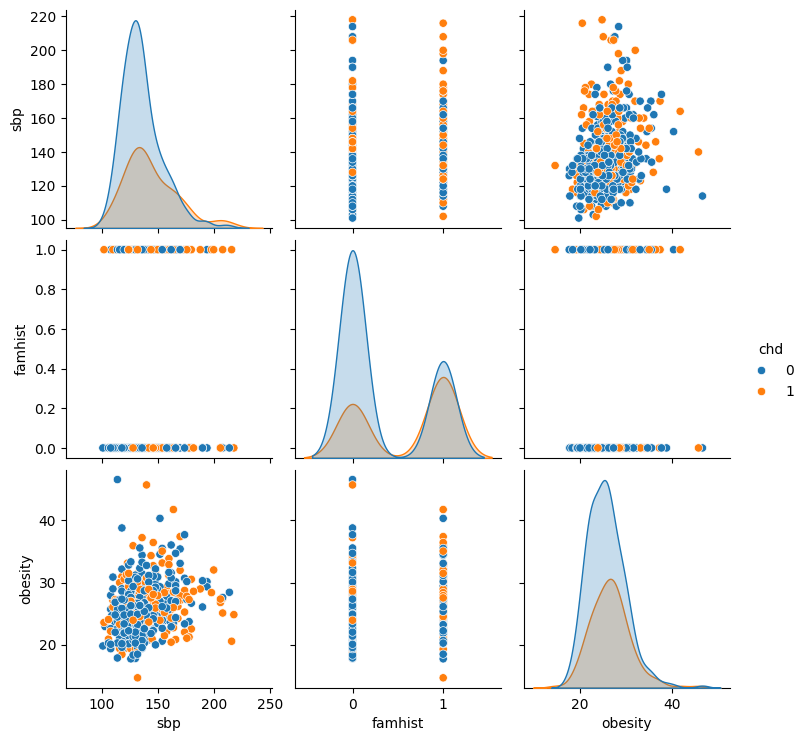

In [3]:
sns.pairplot(df, vars=df.columns[:3], hue=df.columns[-1])

In [4]:
def scale_zero_one(df):
    df2=df.copy()
    for col in df2.columns:
        minCol=min(df[col])
        maxCol=max(df[col])
        df2[col]=(df[col]-minCol)/(maxCol-minCol)
    return df2
df2=scale_zero_one(df)
df2.head()

,sbp,famhist,obesity,age,chd
0,0.504274,1.0,0.332497,0.755102,1.0
1,0.367521,0.0,0.444479,0.979592,1.0
2,0.145299,1.0,0.452949,0.632653,0.0
3,0.589744,1.0,0.542346,0.877551,1.0
4,0.282051,1.0,0.354141,0.693878,1.0


## Analizar
Nuevamente revisamos los datos y observamos que no hay una diferencia significativa para este conjunto de datos.

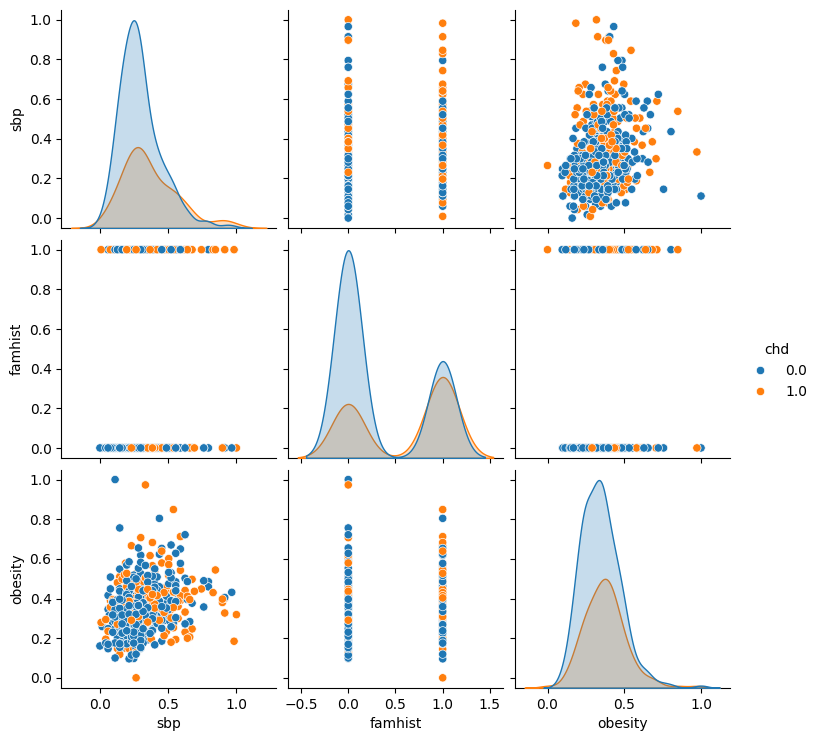

In [5]:
sns.pairplot(df2, vars=df2.columns[:3], hue=df2.columns[-1])

In [6]:
class myKNN():
    '''
    Éste es mi clasificador sencillo de vecinos más cercanos. Busca la mejor k en intervalos de 
    un factor determinado (predeterminado a 5).
    '''
    def __init__(self):
        import numpy as np
        self.best_k=2
        self.best_acc=0
        self.origin=np.array([])
        self.distances=np.array([])
        self.X_pool=[]
        self.y_pool=[]
    
    def setOrigin(self, p1):
        self.origin=p1
            
    def distancePoints(self, p1, p2):
        mySum=0
        for x in range(p1.shape[0]):
            mySum+=((p2[x]-p1[x])**2)
        return mySum**(1/2)
            
    def getOrigin(self):
        return self.origin
    
    def setDistances(self, X):
        self.distances=np.array([])
        for x in range(X.shape[0]):
            self.distances=np.append(self.distances, self.distancePoints(self.origin, X[x,:]))
            
    def getDistances(self):
        return self.distances
    
    def belongsTo(self, sel):
        uniqueVars=np.unique(sel)
        counter=np.zeros(uniqueVars.shape[0])
        for ind in sel:
            counter[np.where(ind == uniqueVars)[0][0]]+=1
        higherCount=np.where(np.max(counter)==counter)[0][0]
        cluster=uniqueVars[higherCount]
        return cluster
    
    # def evaluate(self, k, factor):
    #     X_aux=self.X_pool.copy()
    #     index=np.arange(0,X_aux.shape[0])
    #     train_index=np.random.permutation(index)
    #     train_index=train_index[:int(0.2*index.shape[0])]
    #     accuracy=np.zeros(k)
    #     for ind in train_index:
    #         self.setOrigin(X_aux[ind])
    #         self.setDistances(np.delete(X_aux, ind, axis=0))
    #         db=np.zeros([(index.shape[0]-1),3])
    #         db[:,0]=np.delete(index, ind, axis=0)
    #         db[:,1]=self.distances
    #         db[:,2]=self.y_pool[index!=ind]
    #         db=db[db[:,1].argsort()]
    #         if self.belongsTo(db[:k*factor,2])==self.y_pool[ind]:
    #             accuracy[k-1]+=1
    #     accuracy[k-1]=accuracy[k-1]/train_index.shape[0]
    #     print("Precisión:",accuracy[k-1],'/',1,end="\n\n")
    #     if self.best_acc<accuracy[k-1]:
    #         self.best_acc=accuracy[k-1]
    #         self.best_k=k*factor
    def evaluate(self, k, factor):
        # Aseguramos que X_pool sea array para usar .shape
        X_aux = self.X_pool
        n_samples = X_aux.shape[0]
        index = np.arange(n_samples)
        
        # Mezclamos y tomamos el 20% para validación
        train_index = np.random.permutation(index)
        train_index = train_index[:int(0.2 * n_samples)]
        
        current_k = k * factor
        correct_predictions = 0 # Usaremos este contador simple

        for ind in train_index:
            self.setOrigin(X_aux[ind])

            # 1. Filtramos los datos excluyendo el punto actual
            mask = (index != ind)
            X_others = X_aux[mask]
            y_others = self.y_pool[mask]

            # 2. Calculamos las distancias
            self.setDistances(X_others)
            distancias_calculadas = self.getDistances()

            # 3. Obtenemos los índices de los vecinos más cercanos
            indices_ordenados = np.argsort(distancias_calculadas)

            # 4. Tomamos las etiquetas de los k vecinos
            vecinos_cercanos = y_others[indices_ordenados[:current_k]]

            # 5. Evaluamos la predicción (Comparación directa)
            # Usamos correct_predictions en lugar de accuracy[k-1]
            if self.belongsTo(vecinos_cercanos) == self.y_pool[ind]:
                correct_predictions += 1
        
        # Calculamos el accuracy final de esta iteración
        final_accuracy = correct_predictions / len(train_index)
        
        print(f"K={current_k} | Precisión: {final_accuracy:.4f}")
        
        # Actualizamos el mejor resultado encontrado hasta ahora
        if self.best_acc < final_accuracy:
            self.best_acc = final_accuracy
            self.best_k = current_k
    def fit(self, X, y, factor=5):
        # Convertimos a numpy array para evitar errores de dimensiones
        self.X_pool = np.array(X)
        self.y_pool = np.array(y)
        
        for k in range(1, 11): # Probará k de 5 en 5 hasta 50
            self.evaluate(k, factor)
            
        print("-" * 30)
        print(f"Mejor k determinada: {self.best_k}")
        print(f"Precisión máxima alcanzada: {self.best_acc:.4f}")

    def predict(self, X):
        X = np.array(X)
        predictions = np.zeros(X.shape[0])
        
        # Preparar la lista de clusters según las clases únicas
        clases_unicas = np.unique(self.y_pool)
        cluster = {clase: [] for clase in clases_unicas}

        for ind in range(X.shape[0]):
            self.setOrigin(X[ind])
            self.setDistances(self.X_pool)
            distancias = self.getDistances()
            
            # Obtenemos los índices de los k mejores vecinos
            indices_vecinos = np.argsort(distancias)[:self.best_k]
            
            # Predicción
            clase_predicha = self.belongsTo(self.y_pool[indices_vecinos])
            
            predictions[ind] = clase_predicha
            cluster[clase_predicha].append(ind)
            
        return predictions, cluster

In [7]:
help(myKNN)

Help on class myKNN in module __main__:

class myKNN(builtins.object)
 |  Éste es mi clasificador sencillo de vecinos más cercanos. Busca la mejor k en intervalos de
 |  un factor determinado (predeterminado a 5).
 |
 |  Methods defined here:
 |
 |  __init__(self)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  belongsTo(self, sel)
 |
 |  distancePoints(self, p1, p2)
 |
 |  evaluate(self, k, factor)
 |      # def evaluate(self, k, factor):
 |      #     X_aux=self.X_pool.copy()
 |      #     index=np.arange(0,X_aux.shape[0])
 |      #     train_index=np.random.permutation(index)
 |      #     train_index=train_index[:int(0.2*index.shape[0])]
 |      #     accuracy=np.zeros(k)
 |      #     for ind in train_index:
 |      #         self.setOrigin(X_aux[ind])
 |      #         self.setDistances(np.delete(X_aux, ind, axis=0))
 |      #         db=np.zeros([(index.shape[0]-1),3])
 |      #         db[:,0]=np.delete(index, ind, axis=0)
 |      #         db[:,1]

In [8]:
y_train, y_test = df["chd"][:370], df["chd"][370:]
X_train, X_test = df.values[:370,:], df.values[370:,:]
print("Valores en X")
print("Entrenamiento:", X_train.shape, "Prueba:", X_test.shape, end='\n\n')
print("Valores en y")
print("Entrenamiento:", y_train.shape, "Prueba:", y_test.shape)

Valores en X
Entrenamiento: (370, 5) Prueba: (92, 5)

Valores en y
Entrenamiento: (370,) Prueba: (92,)


In [9]:
clf = myKNN()
clf.fit(X_train, y_train)

K=5 | Precisión: 0.5811
K=10 | Precisión: 0.6757
K=15 | Precisión: 0.5541
K=20 | Precisión: 0.6081
K=25 | Precisión: 0.5811
K=30 | Precisión: 0.7162
K=35 | Precisión: 0.7703
K=40 | Precisión: 0.5541
K=45 | Precisión: 0.6081
K=50 | Precisión: 0.6622
------------------------------
Mejor k determinada: 35
Precisión máxima alcanzada: 0.7703


In [10]:
def accuracy(y, predictions):
    return (np.array([y==predictions]).sum())/y.shape[0]

In [11]:
predictions, clusters = clf.predict(X_test)
print("Precisión:")
accuracy(y_test, predictions)

Precisión:


np.float64(0.7065217391304348)

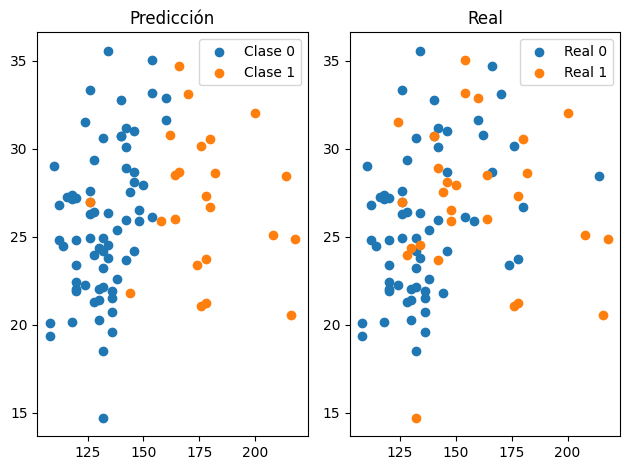

In [12]:
# Gráfica de Predicción
plt.subplot(1, 2, 1)
# Iteramos sobre las llaves (clases) y valores (índices) del diccionario
for clase, indices in clusters.items():
    if len(indices) > 0: # Solo graficamos si hay puntos en ese cluster
        plt.scatter(X_test[indices, 0], X_test[indices, 2], label=f"Clase {clase}")
plt.title("Predicción")
plt.legend()

# Gráfica Real
plt.subplot(1, 2, 2)
clases_reales = np.unique(y_test)
for clase in clases_reales:
    # Creamos una máscara para filtrar los datos reales
    mascara = (y_test == clase)
    plt.scatter(X_test[mascara, 0], X_test[mascara, 2], label=f"Real {clase}")
plt.title("Real")
plt.legend()

plt.tight_layout()
plt.show()

# ID3


In [13]:
data = pd.read_csv('./Data/titanic.csv')

#Mostrar las primeras filas del conjunto de datos
print("Primeras filas del dataset:")
print(data.head())

#Describir las columnas y tipos de datos
print("\nDescripción de las columnas:")
print(data.info())

Primeras filas del dataset:
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest

In [14]:
#Eliminar columnas irrelevantes
data = data.drop(columns=['name', 'ticket', 'cabin'])

#Rellenar valores faltantes en la columna 'Age' con la media
data['age'] = data['age'].fillna(data['age'].mean())

#Rellenar valores faltantes en la columna 'Embarked' con el valor más frecuente
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

#Convertir variables categóricas a numéricas
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['embarked'] = data['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

#Verificar el resultado del preprocesamiento
print("\nDatos después del preprocesamiento:")
print(data.head())


Datos después del preprocesamiento:
   pclass  survived  sex      age  sibsp  parch      fare  embarked boat  \
0       1         1    1  29.0000      0      0  211.3375         2    2   
1       1         1    0   0.9167      1      2  151.5500         2   11   
2       1         0    1   2.0000      1      2  151.5500         2  NaN   
3       1         0    0  30.0000      1      2  151.5500         2  NaN   
4       1         0    1  25.0000      1      2  151.5500         2  NaN   

    body                        home.dest  
0    NaN                     St Louis, MO  
1    NaN  Montreal, PQ / Chesterville, ON  
2    NaN  Montreal, PQ / Chesterville, ON  
3  135.0  Montreal, PQ / Chesterville, ON  
4    NaN  Montreal, PQ / Chesterville, ON  


In [15]:
import math

#Función para calcular la entropía
def calcular_entropia(datos):
    valores, counts = np.unique(datos, return_counts=True)
    total = len(datos)
    entropia = 0
    for count in counts:
        p = count / total
        entropia -= p * math.log2(p)
    return entropia

#Función para calcular la ganancia de información
def calcular_ganancia_info(datos, atributo):
    #Calcular la entropía original
    entropia_original = calcular_entropia(datos)

    #Obtener los valores únicos del atributo
    valores_atributo = np.unique(atributo)
    ganancia_info = entropia_original

    for valor in valores_atributo:
        #Dividir los datos en función de cada valor del atributo
        datos_subgrupo = datos[atributo == valor]
        proporcion = len(datos_subgrupo) / len(atributo)

        #Restar la entropía del subgrupo
        ganancia_info -= proporcion * calcular_entropia(datos_subgrupo)

    return ganancia_info

#Función para construir el árbol ID3
def construir_arbol_ID3(datos, atributos, clase):
    #Si todos los ejemplos tienen la misma clase, devolver una hoja
    if len(np.unique(datos[clase])) == 1:
        return {'clase': np.unique(datos[clase])[0]}

    #Si no quedan atributos, devolver la clase mayoritaria
    if len(atributos) == 0:
        clase_mayoritaria = datos[clase].mode()[0]
        return {'clase': clase_mayoritaria}

    #Calcular la ganancia de información para cada atributo
    ganancia_maxima = -1
    mejor_atributo = None
    for atributo in atributos:
        ganancia = calcular_ganancia_info(datos[clase], datos[atributo])
        if ganancia > ganancia_maxima:
            ganancia_maxima = ganancia
            mejor_atributo = atributo

    #Crear el nodo del árbol
    arbol = {mejor_atributo: {}}
    valores_atributo = np.unique(datos[mejor_atributo])

    #Llamar recursivamente para cada valor del atributo
    for valor in valores_atributo:
        datos_subgrupo = datos[datos[mejor_atributo] == valor]
        atributos_restantes = [a for a in atributos if a != mejor_atributo]
        arbol[mejor_atributo][valor] = construir_arbol_ID3(datos_subgrupo, atributos_restantes, clase)

    return arbol

#Definir las columnas de atributos y la columna de clase
atributos = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
clase = 'survived'

#Construir el árbol ID3
arbol = construir_arbol_ID3(data, atributos, clase)

#Mostrar el árbol resultante
print("\nÁrbol de decisión construido por ID3:")
print(arbol)


Árbol de decisión construido por ID3:
{'fare': {np.float64(0.0): {'age': {np.float64(19.0): {'clase': np.int64(0)}, np.float64(25.0): {'clase': np.int64(1)}, np.float64(29.8811345124283): {'clase': np.int64(0)}, np.float64(36.0): {'clase': np.int64(0)}, np.float64(38.0): {'clase': np.int64(0)}, np.float64(39.0): {'clase': np.int64(0)}, np.float64(40.0): {'clase': np.int64(0)}, np.float64(49.0): {'pclass': {np.int64(1): {'clase': np.int64(1)}, np.int64(3): {'clase': np.int64(0)}}}}}, np.float64(3.1708): {'clase': np.int64(1)}, np.float64(4.0125): {'clase': np.int64(0)}, np.float64(5.0): {'clase': np.int64(0)}, np.float64(6.2375): {'clase': np.int64(0)}, np.float64(6.4375): {'clase': np.int64(0)}, np.float64(6.45): {'clase': np.int64(0)}, np.float64(6.4958): {'clase': np.int64(0)}, np.float64(6.75): {'clase': np.int64(0)}, np.float64(6.8583): {'clase': np.int64(0)}, np.float64(6.95): {'sex': {np.int64(0): {'clase': np.int64(0)}, np.int64(1): {'clase': np.int64(1)}}}, np.float64(6.975): 

In [16]:
from sklearn.tree import DecisionTreeClassifier, export_text

#Crear y entrenar el modelo con sklearn
X = data[atributos]
y = data[clase]

#Crear el modelo
modelo = DecisionTreeClassifier(criterion='entropy', random_state=42)

#Entrenar el modelo
modelo.fit(X, y)

# Mostrar el árbol de decisión
print("\nÁrbol de decisión generado con sklearn:")
print(export_text(modelo, feature_names=atributos))

#Evaluación: Predicciones en los datos de entrenamiento
predicciones = modelo.predict(X)

#Evaluar precisión
from sklearn.metrics import accuracy_score
precision = accuracy_score(y, predicciones)
print("\nPrecisión del modelo:", precision)


Árbol de decisión generado con sklearn:
|--- sex <= 0.50
|   |--- age <= 9.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- fare <= 15.57
|   |   |   |   |--- fare <= 13.12
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- fare >  13.12
|   |   |   |   |   |--- fare <= 14.45
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- fare >  14.45
|   |   |   |   |   |   |--- pclass <= 2.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- pclass >  2.50
|   |   |   |   |   |   |   |--- age <= 6.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- age >  6.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |--- fare >  15.57
|   |   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- age <= 3.50
|   |   |   |   |--- age <= 2.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- age >  2.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- age >  3.50
|   |   |   |   |--- class: 0
|   |--- age >  9.50


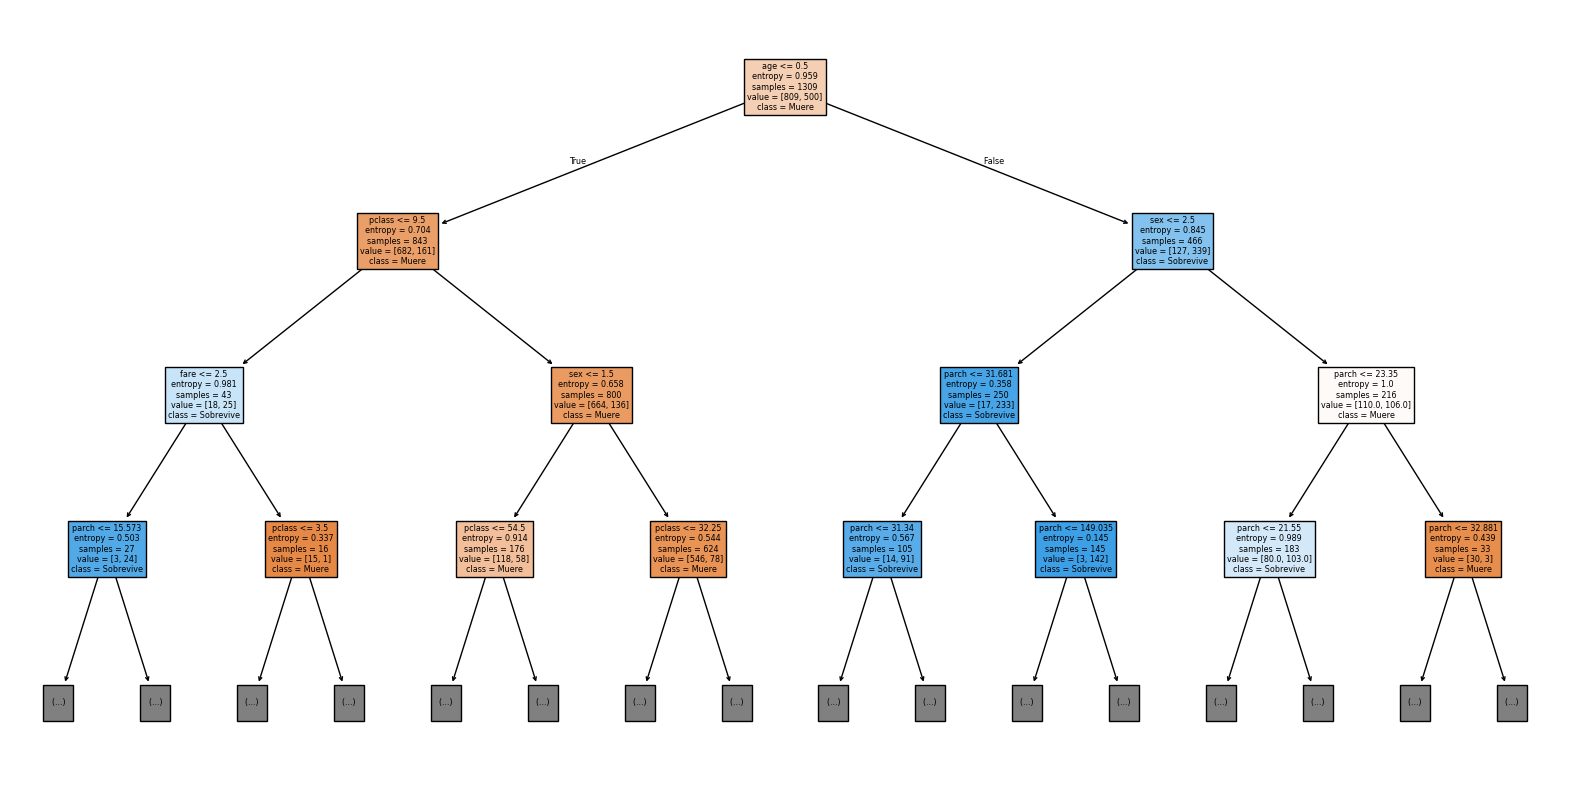

In [17]:
plt.figure(figsize=(20,10))
tree.plot_tree(modelo, 
               feature_names=['sex', 'age', 'pclass', 'fare', 'sibsp', 'parch', 'embarked'],
               class_names=['Muere', 'Sobrevive'],
               filled=True, 
               max_depth=3) # Limitamos la profundidad para que sea legible
plt.show()